# Trends, Business Ideas & What Earns More

**Questions:**
1. What trends are growing over time?
2. What business ideas/services are most common?
3. What ideas earn more? (using team size + stage as proxy)

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

conn = sqlite3.connect("../data/yc_collaboration.db")
df = pd.read_sql("SELECT * FROM companies", conn)
conn.close()

# Parse batch year
df["batch_year"] = df["batch"].str.extract(r"(\d{4})").astype(float)
df["batch_season"] = df["batch"].str.extract(r"(\w+)\s")

# Explode tags into rows
df["tags_list"] = df["tags"].str.split("; ")
tags_df = df.explode("tags_list")
tags_df = tags_df[tags_df["tags_list"].str.strip() != ""]
tags_df = tags_df.dropna(subset=["tags_list"])

print(f"Loaded {len(df)} companies, {len(tags_df)} tag-company pairs")

Loaded 5690 companies, 15313 tag-company pairs


---
## 1. Tag Trends Over Time
Which categories are growing year over year?

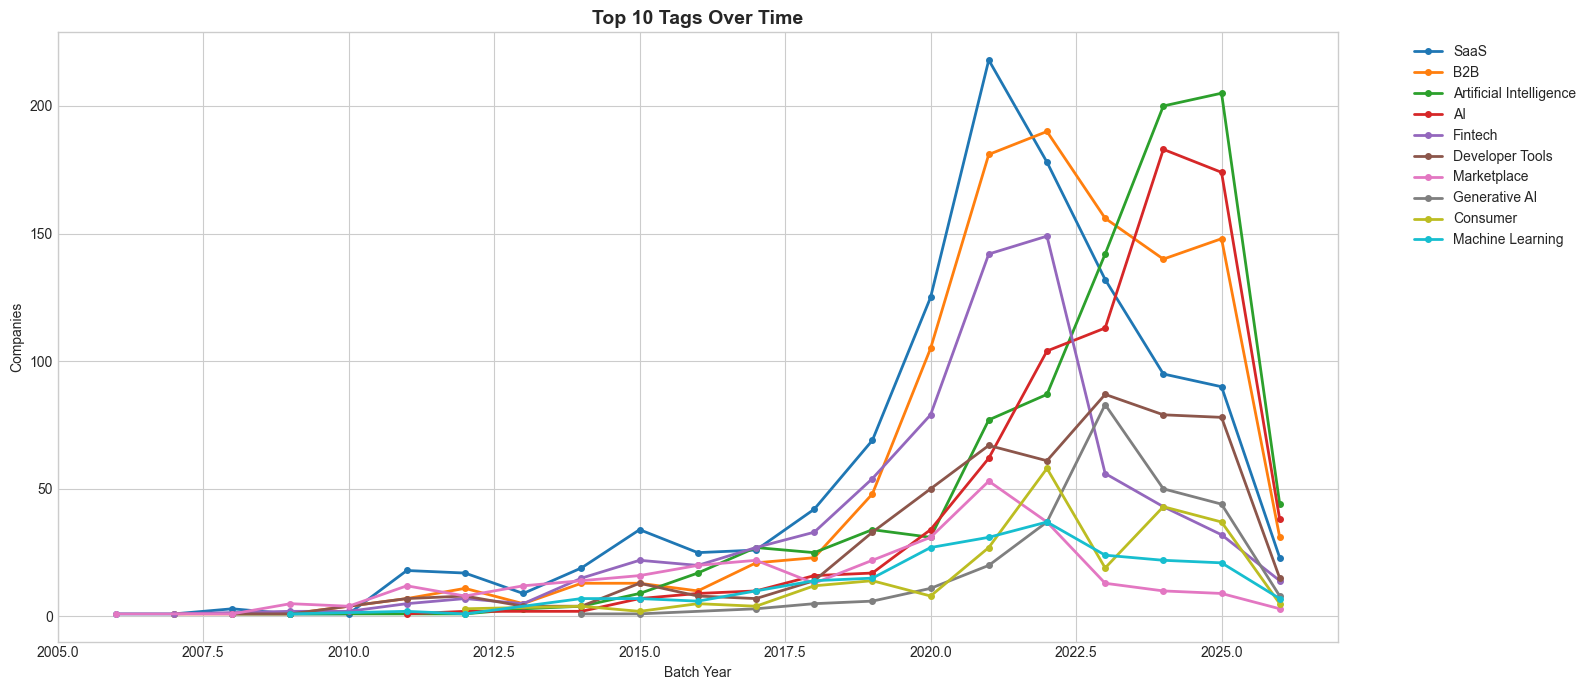

In [33]:
# Count tags per year
tag_year = tags_df.groupby(["batch_year", "tags_list"]).size().reset_index(name="count")

# Top 10 tags overall
top_tags = tags_df["tags_list"].value_counts().head(10).index.tolist()

fig, ax = plt.subplots(figsize=(16, 7))
for tag in top_tags:
    data = tag_year[tag_year["tags_list"] == tag].sort_values("batch_year")
    ax.plot(data["batch_year"], data["count"], marker="o", label=tag, linewidth=2, markersize=4)

ax.set_title("Top 10 Tags Over Time", fontsize=14, fontweight="bold")
ax.set_xlabel("Batch Year")
ax.set_ylabel("Companies")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Fastest Growing Tags (Last 3 Years vs Prior)

In [ ]:
recent = tags_df[tags_df["batch_year"] >= 2023]["tags_list"].value_counts()
older = tags_df[(tags_df["batch_year"] >= 2020) & (tags_df["batch_year"] < 2023)]["tags_list"].value_counts()

# Compare: tags that exist in both periods with min 5 in recent
common = recent.index.intersection(older.index)
growth = ((recent[common] - older[common]) / older[common] * 100).sort_values(ascending=False)
growth = growth[recent[common] >= 5]  # filter noise

print("=== Fastest Growing Tags (2023-2026 vs 2020-2022) ===")
print(f"{'Tag':<30} {'2020-22':>8} {'2023-26':>8} {'Growth':>8}")
print("-" * 58)
for tag in growth.head(20).index:
    print(f"{tag:<30} {older.get(tag, 0):>8} {recent.get(tag, 0):>8} {growth[tag]:>7.0f}%")

In [ ]:
# Visualize top 15 fastest growing
top_growth = growth.head(15)

fig, ax = plt.subplots(figsize=(12, 7))
colors = ["#2d2d2d" if v > 0 else "#999999" for v in top_growth.values]
top_growth.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
ax.set_title("Fastest Growing Tags (2023-2026 vs 2020-2022)", fontsize=14, fontweight="bold")
ax.set_xlabel("Growth %")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Declining Tags

In [ ]:
declining = growth[growth < 0].sort_values()

print("=== Declining Tags (2023-2026 vs 2020-2022) ===")
print(f"{'Tag':<30} {'2020-22':>8} {'2023-26':>8} {'Change':>8}")
print("-" * 58)
for tag in declining.head(15).index:
    print(f"{tag:<30} {older.get(tag, 0):>8} {recent.get(tag, 0):>8} {growth[tag]:>7.0f}%")

---
## 2. Most Common Business Ideas / Services

In [ ]:
# Industry + subindustry breakdown
print("=== Top Industries ===")
print(df["industry"].value_counts().head(10))
print()
print("=== Top Sub-Industries ===")
print(df["subindustry"].value_counts().head(20))

In [ ]:
# Most common tag combinations (business niches)
niche_counts = df[df["tags"] != ""]["tags"].value_counts().head(20)

print("=== Most Common Tag Combinations (Business Niches) ===")
print(f"{'Tags':<60} {'Count':>6}")
print("-" * 68)
for tags, count in niche_counts.items():
    print(f"{tags[:58]:<60} {count:>6}")

In [ ]:
# What subindustries are trending recently?
recent_sub = df[df["batch_year"] >= 2023]["subindustry"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 7))
recent_sub.plot(kind="barh", ax=ax, color="#333333", edgecolor="white")
ax.set_title("Most Common Sub-Industries (2023-2026 Batches)", fontsize=14, fontweight="bold")
ax.set_xlabel("Count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 3. What Ideas Earn More?

No revenue data available, so we use proxies:
- **Team size** = more funding/revenue (bigger team needs more money)
- **Growth stage** = past product-market fit
- **Active + large team** = strong signal of success

In [ ]:
active = df[df["status"] == "Active"].copy()

# Median team size by industry (active only)
industry_size = active.groupby("industry")["team_size"].agg(["median", "mean", "count"]).sort_values("median", ascending=False)
industry_size.columns = ["Median Team", "Mean Team", "Companies"]

print("=== Active Companies: Team Size by Industry ===")
print(industry_size.to_string())

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
industry_size["Median Team"].plot(kind="barh", ax=ax, color="#333333", edgecolor="white")
ax.set_title("Median Team Size by Industry (Active Companies)", fontsize=14, fontweight="bold")
ax.set_xlabel("Median Team Size")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Median team size by sub-industry (top 20, min 10 companies)
sub_size = active.groupby("subindustry")["team_size"].agg(["median", "mean", "count"])
sub_size = sub_size[sub_size["count"] >= 10].sort_values("median", ascending=False)
sub_size.columns = ["Median Team", "Mean Team", "Companies"]

fig, ax = plt.subplots(figsize=(12, 8))
sub_size["Median Team"].head(20).plot(kind="barh", ax=ax, color="#333333", edgecolor="white")
ax.set_title("Top 20 Sub-Industries by Median Team Size (min 10 companies)", fontsize=14, fontweight="bold")
ax.set_xlabel("Median Team Size")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Growth stage ratio by industry (higher = more companies reached Growth)
stage_ratio = active.groupby("industry").apply(
    lambda g: pd.Series({
        "growth_pct": (g["stage"] == "Growth").mean() * 100,
        "total": len(g)
    })
).sort_values("growth_pct", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
stage_ratio["growth_pct"].plot(kind="barh", ax=ax, color="#333333", edgecolor="white")
ax.set_title("% of Active Companies at Growth Stage (by Industry)", fontsize=14, fontweight="bold")
ax.set_xlabel("% at Growth Stage")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Top Tags by Success (Team Size)

In [ ]:
# Which tags correlate with bigger companies?
active_tags = tags_df[tags_df["status"] == "Active"].copy()
tag_success = active_tags.groupby("tags_list")["team_size"].agg(["median", "mean", "count"])
tag_success = tag_success[tag_success["count"] >= 15].sort_values("median", ascending=False)
tag_success.columns = ["Median Team", "Mean Team", "Companies"]

print("=== Tags with Largest Median Team Size (min 15 companies) ===")
print(tag_success.head(25).to_string())

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))
tag_success["Median Team"].head(20).plot(kind="barh", ax=ax, color="#333333", edgecolor="white")
ax.set_title("Top 20 Tags by Median Team Size (Active, min 15 companies)", fontsize=14, fontweight="bold")
ax.set_xlabel("Median Team Size")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Survival Rate by Tag (Which Ideas Last?)

In [ ]:
# Only look at tags with enough data and from batches old enough to measure survival
mature = tags_df[tags_df["batch_year"] <= 2022].copy()  # at least 3+ years old

tag_survival = mature.groupby("tags_list").apply(
    lambda g: pd.Series({
        "survival_rate": (g["status"] == "Active").mean() * 100,
        "total": len(g)
    })
).sort_values("survival_rate", ascending=False)

tag_survival = tag_survival[tag_survival["total"] >= 15]

print("=== Highest Survival Rate by Tag (batches <= 2022, min 15 companies) ===")
print(f"{'Tag':<30} {'Survival %':>12} {'Total':>8}")
print("-" * 52)
for tag, row in tag_survival.head(20).iterrows():
    print(f"{tag:<30} {row['survival_rate']:>11.1f}% {int(row['total']):>8}")

print(f"\n=== Lowest Survival Rate ===")
print(f"{'Tag':<30} {'Survival %':>12} {'Total':>8}")
print("-" * 52)
for tag, row in tag_survival.tail(15).iterrows():
    print(f"{tag:<30} {row['survival_rate']:>11.1f}% {int(row['total']):>8}")

---
## 4. Summary: Best Business Ideas

Combining: trending + large teams + high survival

In [ ]:
# Score tags on 3 dimensions: trend growth, team size, survival
from functools import reduce

# Normalize each metric to 0-100
def normalize(series):
    return (series - series.min()) / (series.max() - series.min()) * 100

# Get tags present in all 3 datasets
common_tags = (
    set(growth.index) &
    set(tag_success.index) &
    set(tag_survival.index)
)

scores = pd.DataFrame(index=list(common_tags))
scores["trend_score"] = normalize(growth[scores.index])
scores["size_score"] = normalize(tag_success.loc[scores.index, "Median Team"])
scores["survival_score"] = normalize(tag_survival.loc[scores.index, "survival_rate"])
scores["overall"] = (scores["trend_score"] * 0.35 + scores["size_score"] * 0.35 + scores["survival_score"] * 0.30)
scores = scores.sort_values("overall", ascending=False)

print("=== Top Business Ideas (Trending + Big Teams + High Survival) ===")
print(f"{'Tag':<30} {'Trend':>7} {'Size':>7} {'Survive':>7} {'Overall':>8}")
print("-" * 62)
for tag, row in scores.head(25).iterrows():
    print(f"{tag:<30} {row['trend_score']:>6.1f} {row['size_score']:>6.1f} {row['survival_score']:>7.1f} {row['overall']:>7.1f}")

In [ ]:
# Visualize top 20
top_scores = scores.head(20)[["trend_score", "size_score", "survival_score"]]

fig, ax = plt.subplots(figsize=(14, 8))
top_scores.plot(kind="barh", stacked=True, ax=ax, colormap="Greys", edgecolor="white")
ax.set_title("Top 20 Business Ideas: Composite Score", fontsize=14, fontweight="bold")
ax.set_xlabel("Score (Trend + Size + Survival)")
ax.invert_yaxis()
ax.legend(["Trend Growth", "Team Size", "Survival Rate"], loc="lower right")
plt.tight_layout()
plt.show()

---
## 5. Most Potential Companies

Actual companies worth looking at — filtered by activity, team size, and recency.

### 5a. Largest Active Companies (Top 30 by Team Size)

In [ ]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", 80)

top_active = df[df["status"] == "Active"].nlargest(30, "team_size")[
    ["name", "one_liner", "website", "team_size", "batch"]
].reset_index(drop=True)
top_active.index += 1
top_active.columns = ["Name", "One-Liner", "Website", "Team Size", "Batch"]
top_active

### 5b. Recently Founded & Growing (2023+ batches, team size >= 10)

In [ ]:
recent_growing = df[
    (df["batch_year"] >= 2023) & (df["status"] == "Active") & (df["team_size"] >= 10)
].sort_values("team_size", ascending=False)[
    ["name", "one_liner", "website", "team_size", "batch"]
].reset_index(drop=True)
recent_growing.index += 1
recent_growing.columns = ["Name", "One-Liner", "Website", "Team Size", "Batch"]
print(f"{len(recent_growing)} recent companies with 10+ team members")
recent_growing

### 5c. Growth-Stage Companies (Past Product-Market Fit)

In [ ]:
growth_companies = df[
    (df["stage"] == "Growth") & (df["status"] == "Active")
].sort_values("team_size", ascending=False)[
    ["name", "one_liner", "website", "team_size", "batch"]
].reset_index(drop=True)
growth_companies.index += 1
growth_companies.columns = ["Name", "One-Liner", "Website", "Team Size", "Batch"]
print(f"{len(growth_companies)} growth-stage active companies")
growth_companies

### 5d. Top Companies in Trending Tags (AI, Automation, Infrastructure)

In [ ]:
trending_tags = ["AI", "Automation", "Infrastructure", "Conversational AI", "Reinforcement Learning", "AIOps"]

trending_companies = df[
    (df["status"] == "Active") &
    (df["tags"].str.contains("|".join(trending_tags), case=False, na=False))
].sort_values("team_size", ascending=False)[
    ["name", "one_liner", "website", "team_size", "batch", "tags"]
].reset_index(drop=True)
trending_companies.index += 1
trending_companies.columns = ["Name", "One-Liner", "Website", "Team Size", "Batch", "Tags"]
print(f"{len(trending_companies)} active companies in trending tags: {', '.join(trending_tags)}")
trending_companies

### 5e. Hidden Gems — Small But Recently Funded & Hiring

In [ ]:
hidden_gems = df[
    (df["batch_year"] >= 2024) & (df["status"] == "Active") &
    (df["is_hiring"] == 1) & (df["team_size"] <= 20)
].sort_values("team_size", ascending=False)[
    ["name", "one_liner", "website", "team_size", "batch"]
].reset_index(drop=True)
hidden_gems.index += 1
hidden_gems.columns = ["Name", "One-Liner", "Website", "Team Size", "Batch"]
print(f"{len(hidden_gems)} recently funded (2024+), hiring, small-team companies")
hidden_gems.head(40)

463 recently funded (2024+), hiring, small-team companies


,Name,One-Liner,Website,Team Size,Batch
1,Spott,AI-native ATS/CRM for recruiting firms,https://spott.io,20.0,Winter 2025
2,AfterQuery,Research lab investigating the boundaries of AI capabilities.,https://afterquery.com,20.0,Winter 2025
3,Onyx,Open Source AI Chat,https://www.onyx.app/,20.0,Winter 2024
4,Toma,AI for Underserved Industries,http://www.toma.com/,20.0,Winter 2024
5,Garage,Building the marketplace that powers America’s most essential assets,https://www.shopgarage.com/,20.0,Winter 2024
6,Reditus Space,Reusable Satellites for zero-g manufacturing,https://www.reditus.space/,20.0,Winter 2025
7,ClaimSorted,Making it easy for insurance companies to process claims,https://claimsorted.com,20.0,Summer 2024
8,Crustdata,Real-time B2B data via simple APIs,https://crustdata.com,20.0,Fall 2024
9,F2,The AI platform for private markets investors,http://f2.ai,20.0,Summer 2025
10,Saturn,Compliance and back office workflows for Wealth Managers.,https://www.SaturnOS.com,18.0,Summer 2024
